In [1]:
EXP_NAME="9MAY"
N = 20000
n_test = 800
n_train = 800
seed = 4
minority_perc = 0.4
# prevalence = 0.10

In [2]:
import sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
  from google.colab import userdata
  from google.colab import drive
  drive.mount('/content/drive')
  PROJECT_ROOT = userdata.get('PROJECT_ROOT')
else:
  PROJECT_ROOT = '../..'

In [3]:
import numpy as np
import pandas as pd
from scipy.stats import skewnorm, gamma, beta, truncnorm
from scipy.special import expit
from scipy.optimize import bisect
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_regression
from sklearn.utils import resample
import matplotlib.pyplot as plt
import seaborn as sns
from data_utils import class_balanced_sampling, proportion_preserving_sampling, scale_dataset, plot_cat_feature, plot_cont_feature, apply_treatment_bias

np.random.seed(seed)

# Generate the clinical ground truth 

## Latent health and outcome

In [4]:
def generate_latent_health(n_pop, S):
  """ 
  Generates the latent health state of the population, underlying cause of the outcome
  """

  # Health Latent driving both clinical manifestion and target outcome
  health_latent = gamma.rvs(a=2, scale=1.5, size=n_pop)

  # Udesc, latent independent of the sensitive attribute
  u_desc = health_latent + gamma.rvs(a=2.1, scale=1, size=n_pop)

  # Ucorr, latent influenced by S
  u_corr = health_latent + np.where(S == 0, 0.3, 1.7) * gamma.rvs(a=1.2, scale=1.0, size=n_pop)

  return health_latent, u_corr, u_desc

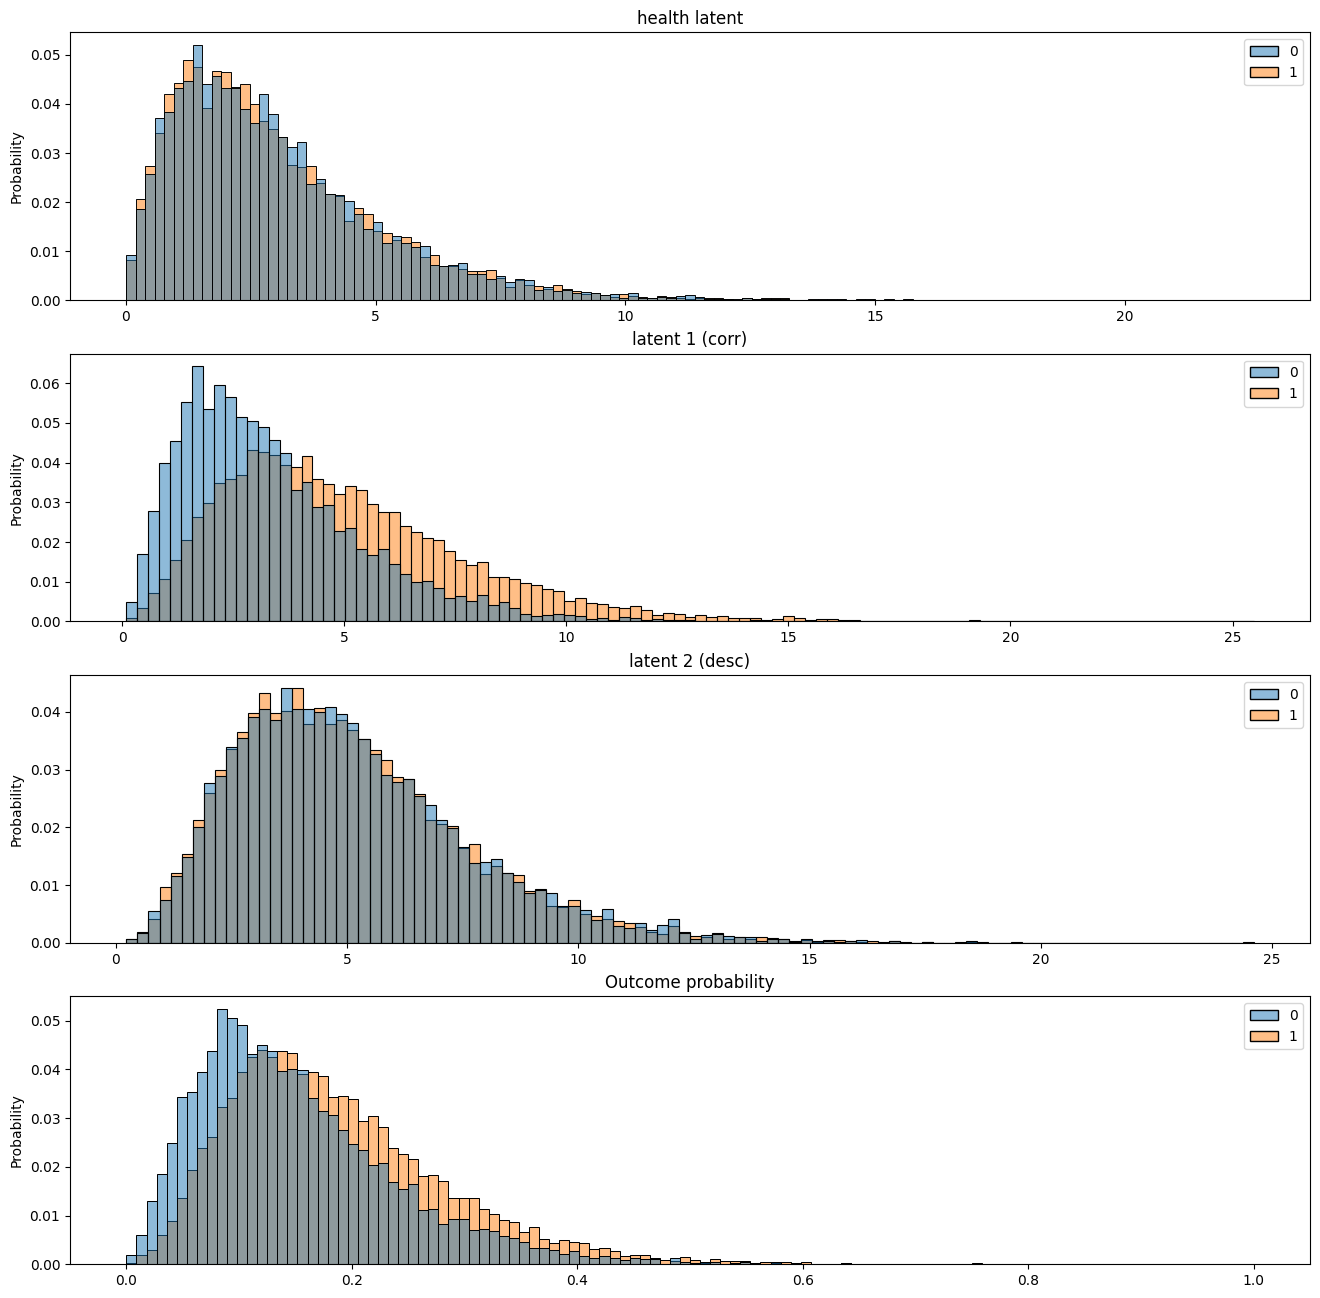

In [5]:
S = np.random.binomial(1, 1 - minority_perc, N)

health_latent, latent_corr, latent_desc = generate_latent_health(N, S)

Y_prob_raw = 2*latent_corr*latent_desc / (latent_corr + latent_desc) 
Y_prob = (Y_prob_raw - Y_prob_raw.min()) / (Y_prob_raw.max() - Y_prob_raw.min())

fig, axes = plt.subplots(4, 1, figsize=(16, 16))
sns.histplot(x=health_latent, common_norm=False, stat="probability", hue=S, ax=axes[0])
sns.histplot(x=latent_corr, common_norm=False, hue=S, stat="probability", ax=axes[1])
sns.histplot(x=latent_desc, common_norm=False, hue=S, stat="probability", ax=axes[2])
sns.histplot(x=Y_prob, common_norm=False, hue=S, stat="probability", ax=axes[3])
axes[0].set_title("health latent")
axes[1].set_title("latent 1 (corr)")
axes[2].set_title("latent 2 (desc)")
axes[3].set_title("Outcome probability")
plt.show()

Outcome prevalence: 10.17%


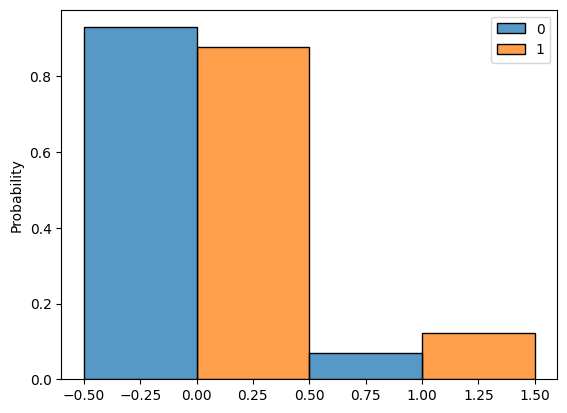

In [6]:
Y = (Y_prob > 0.3).astype(int)

prevalence = round(Y.sum() / len(Y) * 100, 2)
print(f"Outcome prevalence: {prevalence}%")

sns.histplot(x=Y, hue=S, common_norm=False, multiple='dodge', discrete=True, stat='probability')
plt.show()

## Clinical features

In [7]:
def generate_clinical_ground_truth(n_pop, S, latent_corr, latent_desc):

  # Biomarker 1: different means per S group
  biomarker_1 = 40 + 15*S + 5*latent_corr + np.random.normal(0, 10, n_pop)

  # Biomarker 2: independent of S 
  biomarker_2 = np.random.normal(100 + 8 * latent_desc, 15, n_pop)

  return pd.DataFrame({
    'S': S,
    'biomarker_1' : biomarker_1,
    'biomarker_2' : biomarker_2
  })

unbiased_pop = generate_clinical_ground_truth(N, S, latent_corr, latent_desc)
unbiased_pop['Y'] = Y

import os
data_dir = f"{PROJECT_ROOT}/data/synth/{EXP_NAME}"
os.makedirs(data_dir, exist_ok=True)

unbiased_pop.to_csv(f'{data_dir}/simple_unbiased_raw.csv', index=False)


In [8]:
from tableone import TableOne

# Descriptive statistics
table1 = TableOne(unbiased_pop,
                  groupby='S',
                  continuous=['biomarker_1','biomarker_2'],
                  categorical=['Y'],
                  missing=False,
                  sort=True
                  )

print("Population statistical summary")
print("="*80)
print(table1)

Population statistical summary
                          Grouped by S                            
                               Overall             0             1
n                                20000          8019         11981
biomarker_1, mean (SD)     70.8 (19.8)   57.0 (14.7)   80.0 (17.3)
biomarker_2, mean (SD)    140.6 (25.4)  140.7 (25.4)  140.5 (25.3)
Y, n (%)               0  17966 (89.8)   7456 (93.0)  10510 (87.7)
                       1   2034 (10.2)     563 (7.0)   1471 (12.3)



# Unbiased dataset

## Sampling

In [9]:
# --- Unbiased sampling ---
# Stratifying ONLY on S to ensure group representation
unbiased_train, unbiased_test = train_test_split(
    unbiased_pop, 
    train_size=n_train, 
    test_size=n_test, 
    stratify=unbiased_pop['S'], 
    random_state=seed
)

# --- Class-balanced sampling ---
unbiased_bal_train, unbiased_bal_test = class_balanced_sampling(
  unbiased_pop, 
  "Y",
  "S",
  n_train, n_test, seed)

In [26]:
print("=== Unbiased dataset, S-stratified random sampling ===")
print(f"\nTarget Train size: {n_train} | Actual size: {len(unbiased_train)}")
print(f"Prevalence in Training set: {unbiased_train['Y'].mean():.2%}")
print(f"\nTarget Test size: {n_test} | Actual size: {len(unbiased_test)}")
print(f"Prevalence in Test set: {unbiased_test['Y'].mean():.2%}")

print("\n=== Unbiased dataset, class-balanced sampling ===")
print(f"\nTarget Train size: {n_train} | Actual size: {len(unbiased_bal_train)}")
print(f"Prevalence in Training set: {unbiased_bal_train['Y'].mean():.2%}")
print(f"\nTarget Test size: {n_test} | Actual size: {len(unbiased_bal_test)}")
print(f"Prevalence in Test set: {unbiased_bal_test['Y'].mean():.2%}")

=== Unbiased dataset, S-stratified random sampling ===

Target Train size: 800 | Actual size: 800
Prevalence in Training set: 10.75%

Target Test size: 800 | Actual size: 800
Prevalence in Test set: 9.88%

=== Unbiased dataset, class-balanced sampling ===

Target Train size: 800 | Actual size: 800
Prevalence in Training set: 50.00%

Target Test size: 800 | Actual size: 800
Prevalence in Test set: 50.00%


## Distributions

=== Proportion-preserving sampling ===


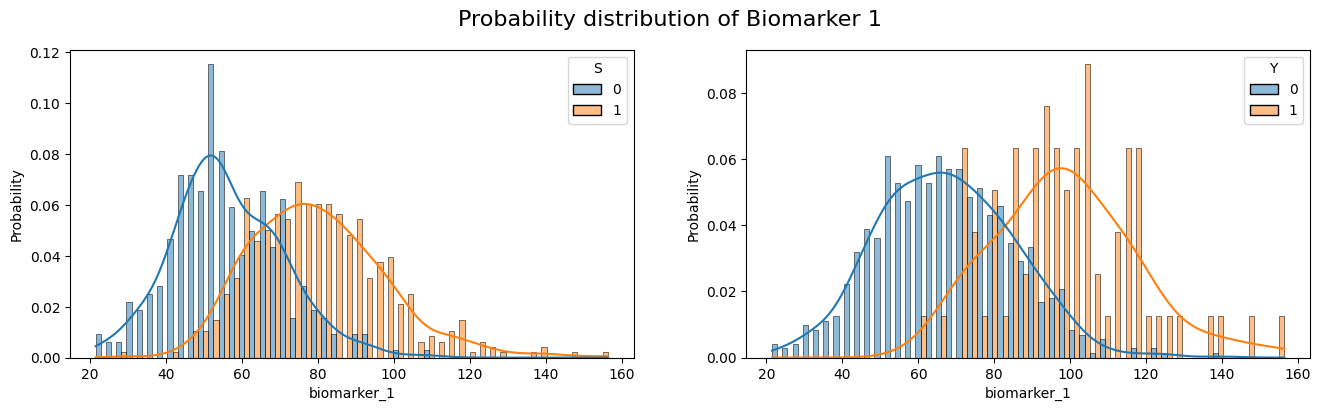

=== Class-balanced sampling ===


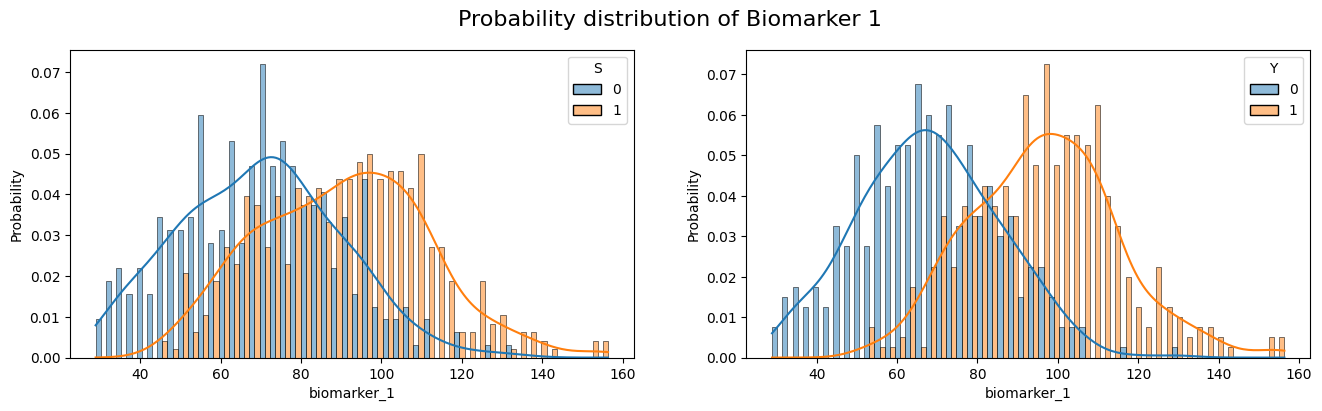

In [11]:
# Biomarker 1, influenced by S
print("=== Proportion-preserving sampling ===")
fig = plot_cont_feature(unbiased_test, 'biomarker_1', "Biomarker 1", "Y")
print("=== Class-balanced sampling ===")
fig = plot_cont_feature(unbiased_bal_test, 'biomarker_1', "Biomarker 1", "Y")

=== Proportion-preserving sampling ===


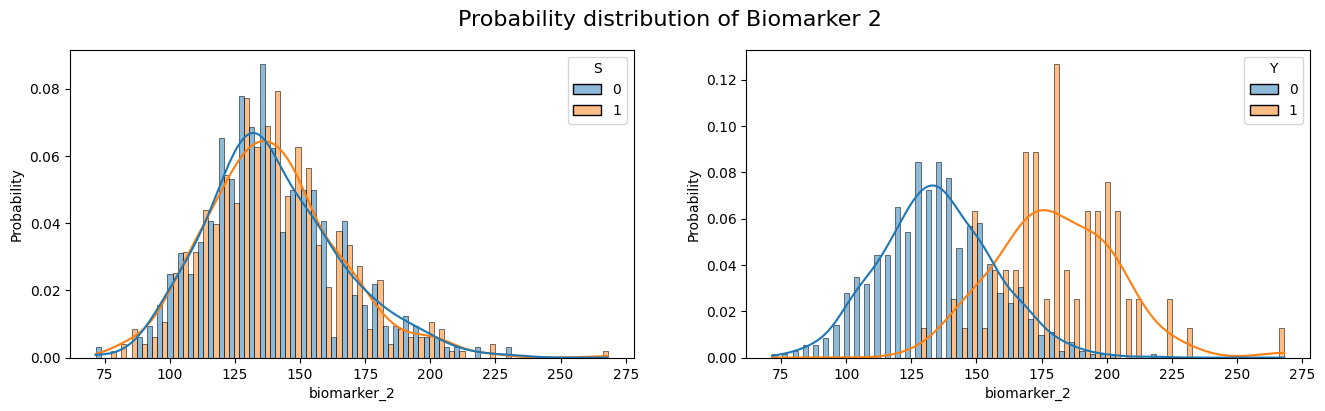

=== Class-balanced sampling ===


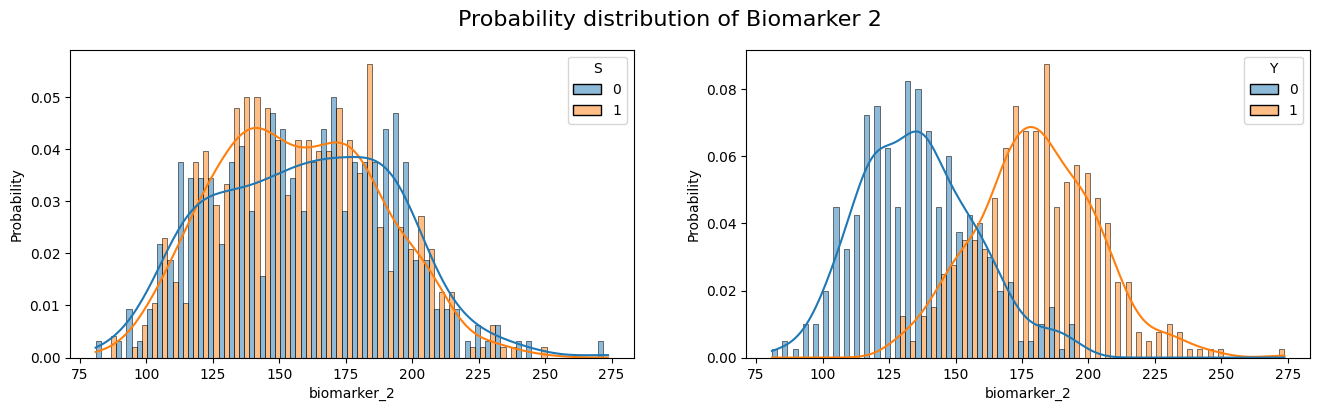

In [12]:
# Biomarker 2, independent from S
print("=== Proportion-preserving sampling ===")
fig = plot_cont_feature(unbiased_test, 'biomarker_2', "Biomarker 2", "Y")
print("=== Class-balanced sampling ===")
fig = plot_cont_feature(unbiased_bal_test, 'biomarker_2', "Biomarker 2", "Y")

## Mutual Information with S

In [29]:
def mutual_info_with_sens(X, sens):
  N_MI = 100
  mi_results = []

  for i in range(N_MI):
    X_resampled, sens_resampled = resample(X, sens, n_samples=50, random_state=i)
    mi_scores = mutual_info_regression(X_resampled, sens_resampled, n_neighbors=5, random_state=seed)
    mi_results.append(mi_scores)

  mi_df = pd.DataFrame(mi_results, columns=X.columns)
  mi_mean = mi_df.mean().sort_values(ascending=False)
  mi_df = mi_df[mi_mean.index]

  print("\n--- Mutual Information with S ---\n")
  print(mi_df.describe().to_markdown())

  plt.figure(figsize=(6, 3))
  ax = sns.barplot(data=mi_df, orient='h', estimator='median', palette='plasma')
  plt.title('Mutual Information Scores with Sensitive Attribute (100 bootstrap samples)')
  plt.show()


--- Mutual Information with S ---

|       |   biomarker_1 |   biomarker_2 |
|:------|--------------:|--------------:|
| count |    100        |   100         |
| mean  |      0.266488 |     0.0207984 |
| std   |      0.08461  |     0.0347299 |
| min   |      0.059808 |     0         |
| 25%   |      0.217136 |     0         |
| 50%   |      0.262343 |     0         |
| 75%   |      0.311336 |     0.0304444 |
| max   |      0.5134   |     0.172028  |


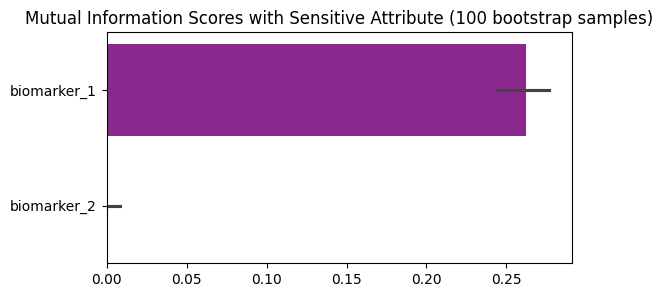

In [30]:
mutual_info_with_sens(
  X=unbiased_test[['biomarker_1', 'biomarker_2']],
  sens=unbiased_test['S']
)


--- Mutual Information with S ---

|       |   biomarker_1 |   biomarker_2 |
|:------|--------------:|--------------:|
| count |   100         | 100           |
| mean  |     0.129286  |   0.0245391   |
| std   |     0.0946079 |   0.0394235   |
| min   |     0         |   0           |
| 25%   |     0.051982  |   0           |
| 50%   |     0.119011  |   0.000346295 |
| 75%   |     0.192844  |   0.0342764   |
| max   |     0.377203  |   0.213792    |


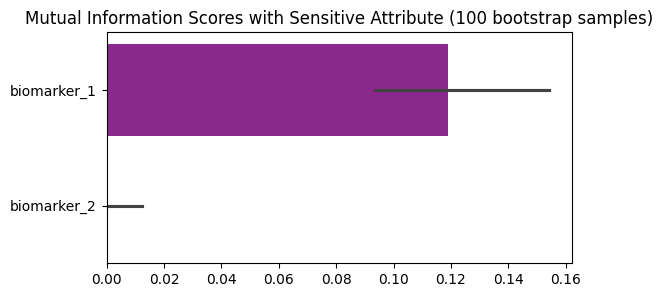

In [31]:
# Biased Dataset, class-balanced sampling
mutual_info_with_sens(
  X=unbiased_bal_test[['biomarker_1', 'biomarker_2']],
  sens=unbiased_bal_test['S']
)

# Biased datasets

## Apply bias to Desc path

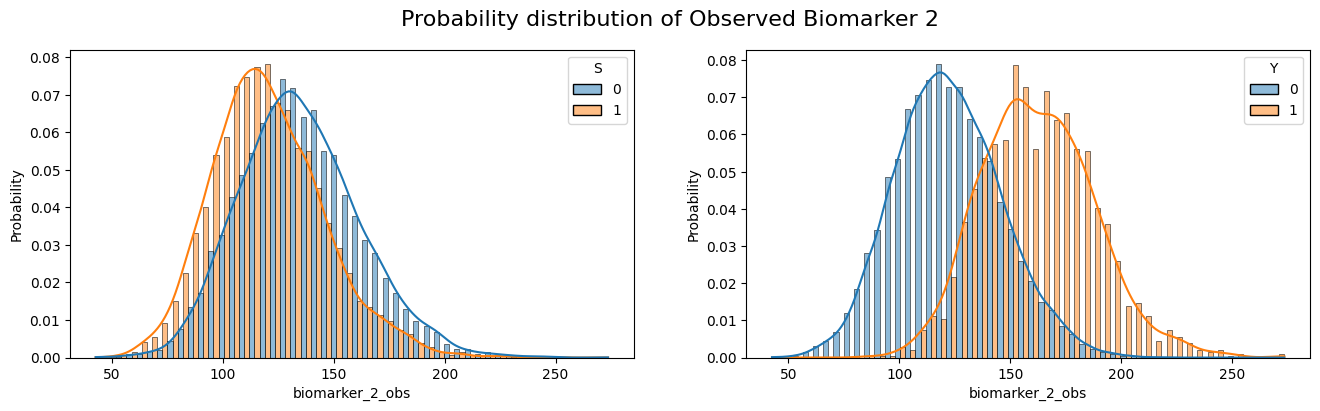

In [16]:
biased_df = apply_treatment_bias(unbiased_pop, "biomarker_2", s_target=0, bias_prob=0.7, b_mean_shift=-20, b_std_shift=3, seed=seed)

fig = plot_cont_feature(biased_df, "biomarker_2_obs", "Observed Biomarker 2", "Y")

## Sampling

In [17]:
# --- Unbiased sampling ---
# Stratifying ONLY on S to ensure group representation
biased_train, biased_test = train_test_split(
    biased_df, 
    train_size=n_train, 
    test_size=n_test, 
    stratify=biased_df['S'], 
    random_state=seed
)

# --- Class-balanced sampling ---
biased_classbal_train, biased_classbal_test = class_balanced_sampling(
  biased_df, 
  "Y",
  "S",
  n_train, n_test, seed)

In [18]:
print("=== Unbiased dataset, proportion-preserving sampling ===")
print(f"Target Train size: {n_train} | Actual size: {len(biased_train)}")
print(f"Prevalence in Training set: {biased_train['Y'].mean():.2%}")
print(f"Target Test size: {n_test} | Actual size: {len(biased_test)}")
print(f"Prevalence in Test set: {biased_test['Y'].mean():.2%}")

print("=== Unbiased dataset, class-balanced sampling ===")
print(f"Target Train size: {n_train} | Actual size: {len(biased_classbal_train)}")
print(f"Prevalence in Training set: {biased_classbal_train['Y'].mean():.2%}")
print(f"Target Test size: {n_test} | Actual size: {len(biased_classbal_test)}")
print(f"Prevalence in Test set: {biased_classbal_test['Y'].mean():.2%}")

=== Unbiased dataset, proportion-preserving sampling ===
Target Train size: 800 | Actual size: 800
Prevalence in Training set: 10.75%
Target Test size: 800 | Actual size: 800
Prevalence in Test set: 9.88%
=== Unbiased dataset, class-balanced sampling ===
Target Train size: 800 | Actual size: 800
Prevalence in Training set: 50.00%
Target Test size: 800 | Actual size: 800
Prevalence in Test set: 50.00%


## Test Distributions

======= PROPORTION PRESERVING SAMPLING =======
Biomarker 1


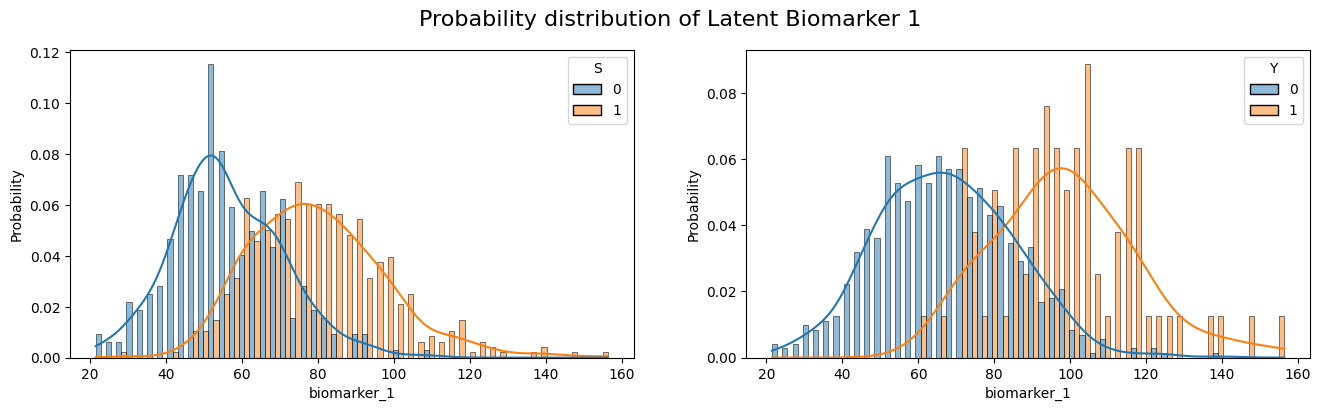

Unbiased biomarker 2


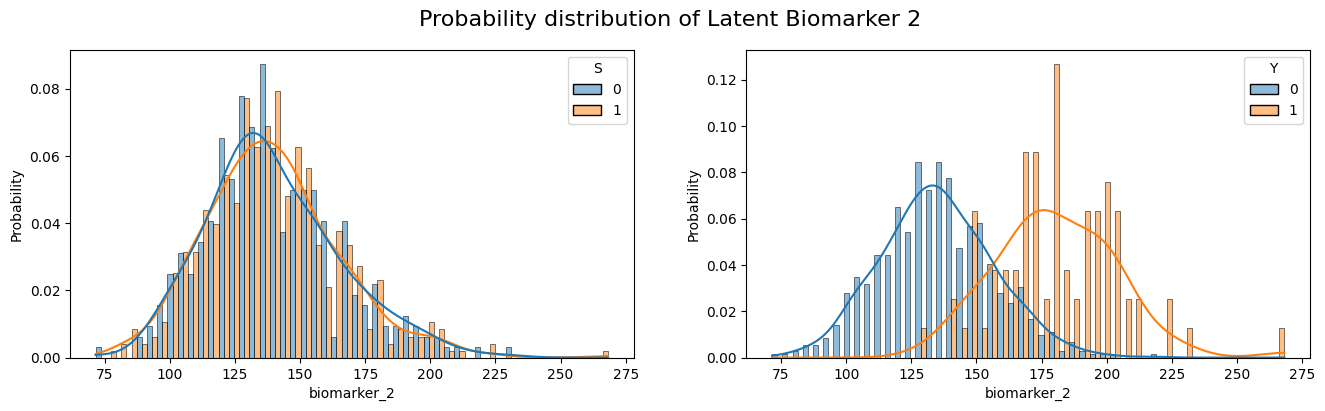

Biased biomarker 2


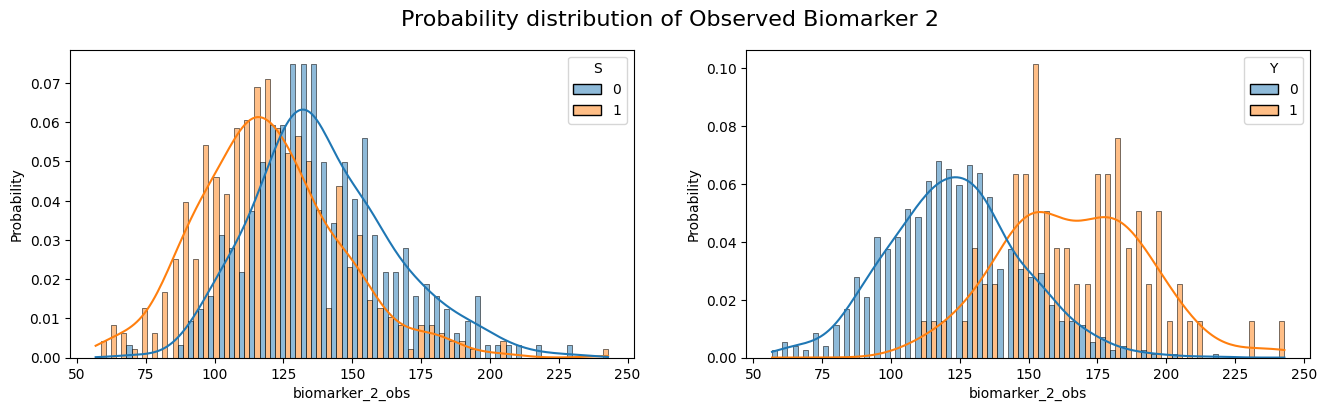

======= CLASS-BALANCED SAMPLING =======
Biomarker 1


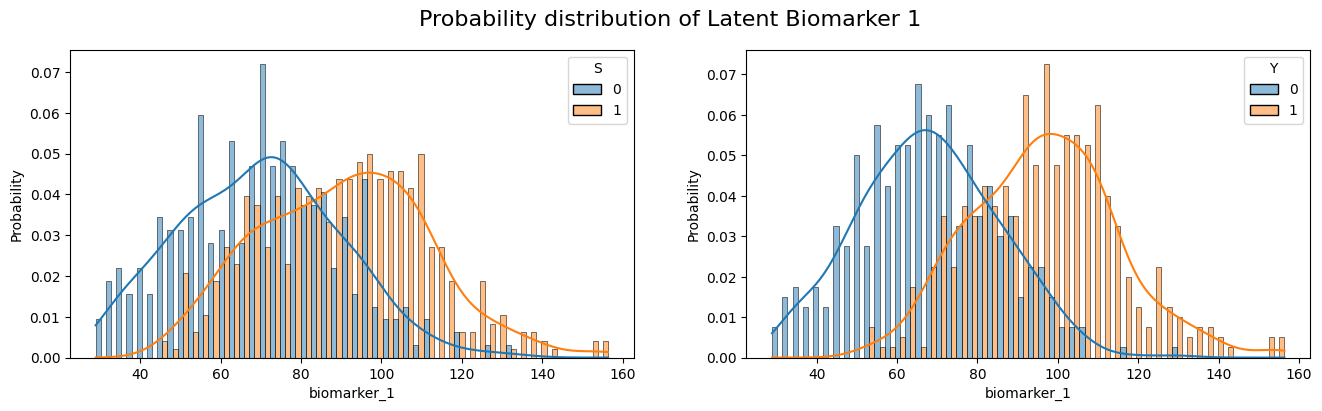

Unbiased biomarker 2


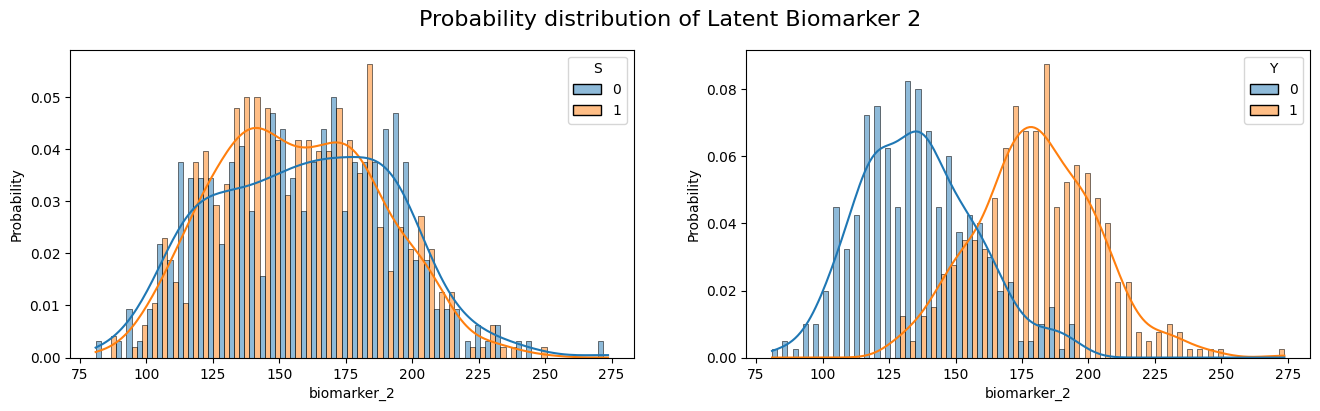

Biased biomarker 2


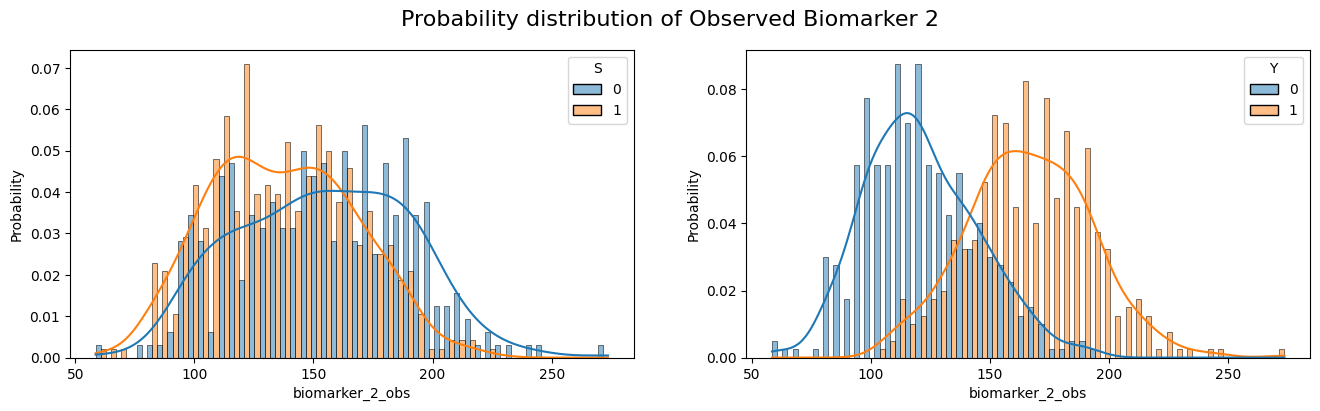

In [19]:
print(f'======= PROPORTION PRESERVING SAMPLING =======')
print(f'Biomarker 1')
fig = plot_cont_feature(biased_test, "biomarker_1", "Latent Biomarker 1", "Y")
print(f'Unbiased biomarker 2')
fig = plot_cont_feature(biased_test, "biomarker_2", "Latent Biomarker 2", "Y")
print(f'Biased biomarker 2')
fig = plot_cont_feature(biased_test, "biomarker_2_obs", "Observed Biomarker 2", "Y")
print(f'======= CLASS-BALANCED SAMPLING =======')
print(f'Biomarker 1')
fig = plot_cont_feature(biased_classbal_test, "biomarker_1", "Latent Biomarker 1", "Y")
print(f'Unbiased biomarker 2')
fig = plot_cont_feature(biased_classbal_test, "biomarker_2", "Latent Biomarker 2", "Y")
print(f'Biased biomarker 2')
fig = plot_cont_feature(biased_classbal_test, "biomarker_2_obs", "Observed Biomarker 2", "Y")

## Mutual Information with S


--- Mutual Information with S ---

|       |   biomarker_1 |   biomarker_2_obs |   biomarker_2 |
|:------|--------------:|------------------:|--------------:|
| count |   100         |       100         |   100         |
| mean  |     0.266469  |         0.0894667 |     0.020992  |
| std   |     0.0846279 |         0.0767587 |     0.0347294 |
| min   |     0.059808  |         0         |     0         |
| 25%   |     0.217136  |         0.0232629 |     0         |
| 50%   |     0.262343  |         0.0687551 |     0         |
| 75%   |     0.311336  |         0.138876  |     0.0304444 |
| max   |     0.5134    |         0.318981  |     0.172028  |


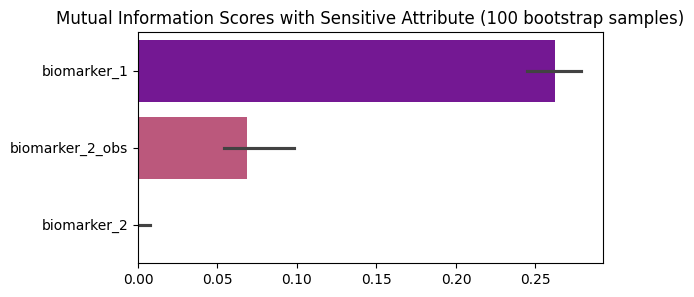

In [32]:
# Biased Dataset, random sampling
mutual_info_with_sens(
  X=biased_test[['biomarker_1', 'biomarker_2', 'biomarker_2_obs']],
  sens=biased_test['S']
)


--- Mutual Information with S ---

|       |   biomarker_1 |   biomarker_2_obs |   biomarker_2 |
|:------|--------------:|------------------:|--------------:|
| count |   100         |       100         | 100           |
| mean  |     0.129265  |         0.0502852 |   0.0245024   |
| std   |     0.0945964 |         0.0553674 |   0.0394371   |
| min   |     0         |         0         |   0           |
| 25%   |     0.051982  |         0         |   0           |
| 50%   |     0.119011  |         0.0360026 |   5.34905e-05 |
| 75%   |     0.192844  |         0.088888  |   0.0342764   |
| max   |     0.377203  |         0.21097   |   0.213792    |


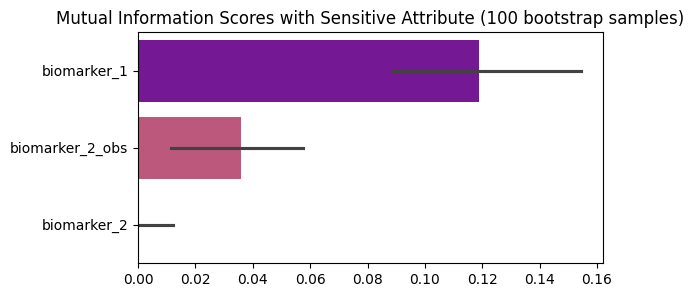

In [33]:
# Biased Dataset, class-balanced sampling
mutual_info_with_sens(
  X=biased_classbal_test[['biomarker_1', 'biomarker_2', 'biomarker_2_obs']],
  sens=biased_classbal_test['S']
)

# Scaling

In [22]:
minmax_features = ['biomarker_1']
standard_features = []
skewed_features = ['biomarker_2']

unbiased_train_processed, unbiased_test_processed = scale_dataset(
  unbiased_train, unbiased_test, 
  minmax_features=minmax_features,
  standard_features=standard_features,
  skewed_features=skewed_features)

minmax_features = ['biomarker_1', 'biomarker_2']
standard_features = []
skewed_features = []

unbiased_classbal_train_processed, unbiased_classbal_test_processed = scale_dataset(
  unbiased_bal_train, unbiased_bal_test, 
  minmax_features=minmax_features,
  standard_features=standard_features,
  skewed_features=skewed_features)

unbiased_train_processed.to_csv(f'{data_dir}/simple_unbiased_test.csv', index=False)
unbiased_test_processed.to_csv(f'{data_dir}/simple_unbiased_train.csv', index=False)
unbiased_classbal_train_processed.to_csv(f'{data_dir}/simple_unbiased_classbal_train.csv', index=False)
unbiased_classbal_test_processed.to_csv(f'{data_dir}/simple_unbiased_classbal_test.csv', index=False)

In [23]:
minmax_features = ['biomarker_1', 'biomarker_2_obs']
standard_features = []
skewed_features = []

biased_train_processed, biased_test_processed = scale_dataset(
  biased_train, biased_test, 
  minmax_features=minmax_features,
  standard_features=standard_features,
  skewed_features=skewed_features)
biased_classbal_test_processed, biased_classbal_train_processed = scale_dataset(
  biased_classbal_train, biased_classbal_test, 
  minmax_features=minmax_features,
  standard_features=standard_features,
  skewed_features=skewed_features)

biased_train_processed.to_csv(f'{data_dir}/simple_biased_test.csv', index=False)
biased_test_processed.to_csv(f'{data_dir}/simple_biased_train.csv', index=False)
biased_classbal_train_processed.to_csv(f'{data_dir}/simple_biased_classbal_train.csv', index=False)
biased_classbal_test_processed.to_csv(f'{data_dir}/simple_biased_classbal_test.csv', index=False)